Data shape: torch.Size([10000, 2])
Training diffusion model...
Epoch 0/5000, Loss: 1.041939
Epoch 500/5000, Loss: 0.195021
Epoch 1000/5000, Loss: 0.164554
Epoch 1500/5000, Loss: 0.165352
Epoch 2000/5000, Loss: 0.226516
Epoch 2500/5000, Loss: 0.178737
Epoch 3000/5000, Loss: 0.174049
Epoch 3500/5000, Loss: 0.201776
Epoch 4000/5000, Loss: 0.137265
Epoch 4500/5000, Loss: 0.181831

Generating samples...
Denoising step 200/1000
Denoising step 400/1000
Denoising step 600/1000
Denoising step 800/1000
Denoising step 1000/1000
Saved visualization to diffusion_2d_toy.png


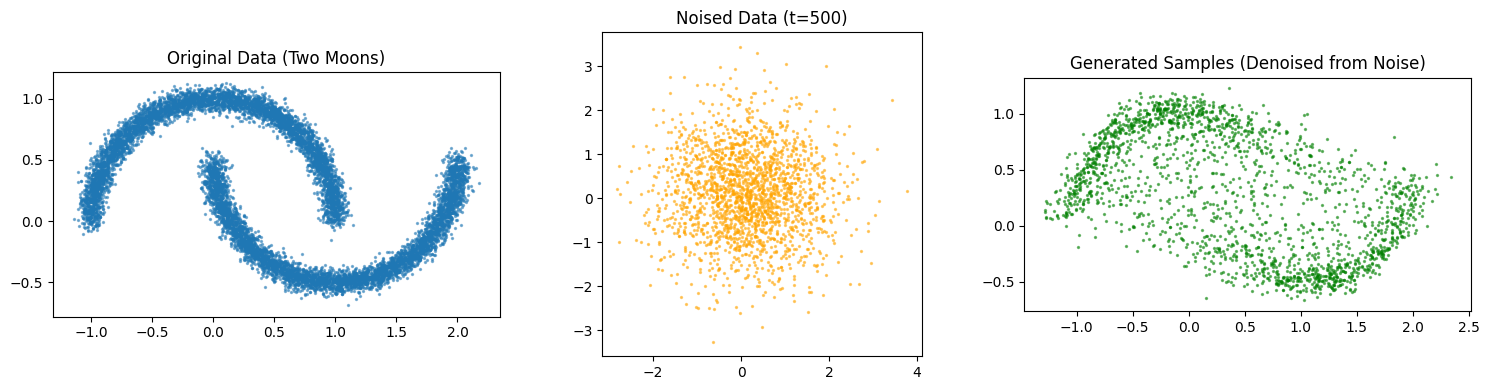

In [ ]:
# Lab 4.4: Tiny DDPM on 2D Toy Data
# Visualizes the diffusion process step-by-step
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

# 1. CONFIG
T = 1000 # number of diffusion steps
BETA_START = 1e-4
BETA_END = 0.02
DEVICE = "cpu"
HIDDEN_DIM = 128
EPOCHS = 5000
BATCH_SIZE = 256

# GENERATE TOY DATA
def generate_data(n_samples=10000):
    """Generate 2D toy data: two moons."""
    X, _ = make_moons(n_samples=n_samples, noise=0.05)
    return torch.tensor(X, dtype=torch.float32)

data = generate_data(10000).to(DEVICE)
print(f"Data shape: {data.shape}")

# DEFINE DIFFUSION SCHEDULE
betas = torch.linspace(BETA_START, BETA_END, T, device=DEVICE)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)

# Precompute useful quantities
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

# FORWARD DIFFUSION (add noise)
def q_sample(x0, t, noise=None):
    """Sample from q(x_t | x_0) ~ N(sqrt(alpha_bar_t) * x0, (1 - alpha_bar_t) * I)."""
    if noise is None:
        noise = torch.randn_like(x0)
    sqrt_alpha_t = sqrt_alphas_cumprod[t].view(-1, 1)
    sqrt_one_minus_alpha_t = sqrt_one_minus_alphas_cumprod[t].view(-1, 1)
    return sqrt_alpha_t * x0 + sqrt_one_minus_alpha_t * noise, noise

# DENOISING MODEL (simple MLP)
class NoisePredictionMLP(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=128, time_dim=32):
        super().__init__()
        self.time_embed = nn.Sequential(
            nn.Linear(1, time_dim),
            nn.ReLU(),
            nn.Linear(time_dim, time_dim),
        )
        self.net = nn.Sequential(
            nn.Linear(input_dim + time_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x, t):
        t_emb = self.time_embed(t.float().unsqueeze(-1) / T)
        x_cat = torch.cat([x, t_emb], dim=-1)
        return self.net(x_cat)

model = NoisePredictionMLP(hidden_dim=HIDDEN_DIM).to(DEVICE)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# TRAINING LOOP
print("Training diffusion model...")
for epoch in range(EPOCHS):
    # Sample random batch
    idx = torch.randint(0, len(data), (BATCH_SIZE,))
    x0 = data[idx]

    # Sample random timestep
    t = torch.randint(0, T, (BATCH_SIZE,), device=DEVICE)

    # Forward diffusion: add noise
    xt, noise = q_sample(x0, t)

    # Predict noise
    noise_pred = model(xt, t)

    # Loss: MSE between true noise and predicted noise
    loss = nn.functional.mse_loss(noise_pred, noise)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"Epoch {epoch}/{EPOCHS}, Loss: {loss.item():.6f}")

# SAMPLING (reverse diffusion)
@torch.no_grad()
def p_sample(model, x, t):
    """Single reverse diffusion step."""
    t_tensor = torch.full((x.shape[0],), t, device=DEVICE, dtype=torch.long)
    noise_pred = model(x, t_tensor)

    alpha_t = alphas[t]
    alpha_bar_t = alphas_cumprod[t]

    # Mean of p(x_{t-1} | x_t)
    mean = (1 / torch.sqrt(alpha_t)) * (x - ((1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)) * noise_pred)

    if t > 0:
        noise = torch.randn_like(x)
        sigma_t = torch.sqrt(betas[t])
        return mean + sigma_t * noise
    else:
        return mean

@torch.no_grad()
def sample(model, n_samples=1000):
    """Generate samples by running reverse diffusion from noise."""
    x = torch.randn(n_samples, 2, device=DEVICE)
    for t in reversed(range(T)):
        x = p_sample(model, x, t)
        if t % 200 == 0:
            print(f"Denoising step {T-t}/{T}")
    return x

print("\nGenerating samples...")
samples = sample(model, n_samples=2000).cpu().numpy()

# VISUALIZATION
fig, axes = plt.subplots(1, 3, figsize=(15,4))

# Original data
axes[0].scatter(data[:, 0].cpu(), data[:, 1].cpu(), s=2, alpha=0.5)
axes[0].set_title("Original Data (Two Moons)")
axes[0].set_aspect('equal')

# Noised data (t=T/2)
xt_mid, _ = q_sample(data[:2000], torch.full((2000,), T//2, device=DEVICE))
axes[1].scatter(xt_mid[:, 0].cpu(), xt_mid[:, 1].cpu(), s=2, alpha=0.5, color='orange')
axes[1].set_title(f"Noised Data (t={T//2})")
axes[1].set_aspect('equal')

# Generated samples
axes[2].scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.5, color='green')
axes[2].set_title("Generated Samples (Denoised from Noise)")
axes[2].set_aspect('equal')

plt.tight_layout()
plt.savefig("diffusion_2d_toy.png", dpi=150)
print("Saved visualization to diffusion_2d_toy.png")
plt.show()